In [1]:
import pandas as pd
import numpy as np

In [3]:
def simulate_labels(df, seed=42):
    """
    Given a DataFrame with:
      - df['verified_purchase'] (bool)
      - df['rating'] (float 1–5)
      - df['helpful_vote'] (int)
    this function will add three new columns:
      - 'clicked'      (0/1)
      - 'add_to_cart'  (0/1)
      - 'favorite'     (0/1)
    Simulation follows a funnel:
      impression → click → add_to_cart → favorite → purchase
    """
    np.random.seed(seed)

    # Normalize rating to [0, 1] to use as a "bonus"
    df['rating_norm'] = (df['rating'].fillna(3.0) - 1) / 4.0

    # Normalize helpful_vote to [0, 1]
    max_helpful = df['helpful_vote'].max() or 1
    df['helpful_norm'] = df['helpful_vote'] / max_helpful

    # Base funnel probabilities
    p_click_base = 0.3
    p_cart_base = 0.15
    p_fav_base = 0.10

    # Compute per_row probabilities with bonuses
    # More highly rated and voted items get a boost
    df['p_click'] = (p_click_base + 0.4 * df['rating_norm'] + 0.2 * df['helpful_norm']).clip(0,1)
    df['p_cart']     = (p_cart_base  + 0.3 * df['rating_norm'] + 0.1 * df['helpful_norm']).clip(0,1)
    df['p_favorite'] = (p_fav_base   + 0.2 * df['rating_norm'] + 0.1 * df['helpful_norm']).clip(0,1)

    # Simulate each step of the funnel
    clicks, carts, favs = [], [], []

    for _, row in df.iterrows():
        click = np.random.rand() < row['p_click']
        # Add to cart only if clicked
        cart = click and (np.random.rand() < row['p_cart'])
        # Favorite only if added to cart
        fav = cart and (np.random.rand() < row['p_favorite'])
        purchase = bool(row['verified_purchase'])

        # If purchase happened but cart was False, force cart = True
        if purchase and not cart:
            cart = True
        
        # If cart happened but click was False, force = True
        if cart and not click:
            click = True
        
        # If favorite happened but click was False, force click and cart to be True
        if fav and not cart:
            cart = True
        if fav and not click:
            click = True 
        
        clicks.append(int(click))
        carts.append(int(cart))
        favs.append(int(fav))
    
    df['clicked'] = clicks
    df['add_to_cart'] = carts
    df['favorite'] = favs

    return df 



In [10]:
#df = pd.read_json("../RetrievalModel/Data/All_Beauty_UserReview.jsonl", lines=True)
df = pd.read_excel("Data/top30k_user_labels.xlsx")
df = simulate_labels(df)

In [18]:
#df.drop(columns=[ 'action_label'], inplace=True)
df.to_excel("Data/top30k_user_labels.xlsx", index=False)

In [12]:
df.head()

,Unnamed: 0.1,Unnamed: 0,rating,title,text,images,asin,parent_asin,user_id,timestamp,...,p_click,p_cart,p_fav,action_label,rating_norm,helpful_norm,p_favorite,clicked,add_to_cart,favorite
0,0,3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,...,0.300000,0.150000,0.100,4,0.00,0.000000,0.100000,1,1,0
1,1,32,1,halo hair extensions,"This halo hair extension is simply put, garbag...",[],B0BFR5WF1R,B0BFR5WF1R,AFZUK3MTBIBEDQOPAK3OATUOUKLA,2023-02-08 03:18:53.052,...,0.304706,0.152353,0.100,4,0.00,0.023529,0.102353,1,1,0
2,2,68,4,Hydrating!,This lip butter is pretty much a lip gloss. I ...,[],B0B8DCC531,B0B8DZ7H5F,AHV6QCNBJNSGLATP56JAWJ3C4G2A,2022-09-14 13:59:16.007,...,0.600000,0.375000,0.175,0,0.75,0.000000,0.250000,0,0,0
3,3,69,5,Luxurious!,I am enjoying this face cream. I find it to be...,[],B0B4JP5YD9,B0B4JP5YD9,AHV6QCNBJNSGLATP56JAWJ3C4G2A,2022-08-13 19:10:31.321,...,0.700000,0.450000,0.200,2,1.00,0.000000,0.300000,1,1,1
4,4,70,4,Good Way to Use a Face Oil,This is a good way to use a face oil. Normally...,[],B0B4JPGX8P,B0B4JPGX8P,AHV6QCNBJNSGLATP56JAWJ3C4G2A,2022-08-13 19:07:52.640,...,0.600000,0.375000,0.175,0,0.75,0.000000,0.250000,1,0,0


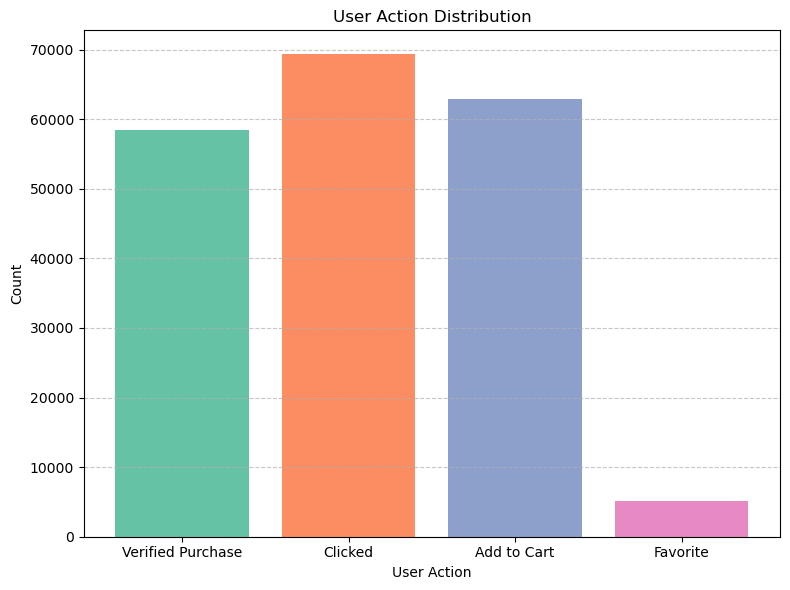

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset (replace this with your actual DataFrame if already loaded)
# df = pd.read_csv("your_user_data.csv")

# Example: if you already have a DataFrame, skip loading
# Columns: ['verified_purchase', 'clicked', 'add_to_cart', 'favorite']

# Count the number of 1s in each action column
action_counts = {
    'Verified Purchase': df['verified_purchase'].sum(),
    'Clicked': df['clicked'].sum(),
    'Add to Cart': df['add_to_cart'].sum(),
    'Favorite': df['favorite'].sum()
}

# Plotting
plt.figure(figsize=(8, 6))
plt.bar(action_counts.keys(), action_counts.values(), color=['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'])
plt.title('User Action Distribution')
plt.xlabel('User Action')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [14]:
action_counts

{'Verified Purchase': np.int64(58474),
 'Clicked': np.int64(69299),
 'Add to Cart': np.int64(62901),
 'Favorite': np.int64(5134)}

In [1]:
int(True)

1